# How Much Does a Better Forecast Help?

This companion revisits battery arbitrage with uncertain prices. At each decision hour, we build scenarios only from older prices, implement one action, observe the realized price, and replan.

The notebook separates three questions:

* What is the value of perfect information at one forecast origin?
* Does modeling forecast uncertainty improve the first action?
* How do the policies perform out of sample in a rolling backtest?

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 8 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

## Learning goals

* Put shared first-stage decisions on the root model and recourse on scenario `Block`s.
* Distinguish a two-stage approximation from a multistage scenario tree.
* Compute RP, EEV, WS, VSS, and EVPI with the profit convention.
* Prevent simultaneous charging and discharging, including at negative prices.
* Compare expected-value, stochastic, risk-averse, and perfect-forecast policies.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo

if "google.colab" in sys.modules:
    !wget -q https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py
    import helper
    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper

helper.set_plotting_style()

SOLVER = pyo.SolverFactory("appsi_highs")
assert SOLVER.available(exception_flag=False), 'Install HiGHS before running this notebook.'

## Data and information pattern

The repository carries hourly 2015 CAISO day-ahead prices for one node.

At decision hour $t$:

* the seven scenarios are 24-hour windows beginning at the same hour on the previous seven days;
* every scenario ends at or before $t$;
* the realized window beginning at $t$ is reserved for evaluation; and
* an oracle policy may use that window only as an unattainable benchmark.

This historical ensemble is transparent, not a claim of forecasting state of the art.

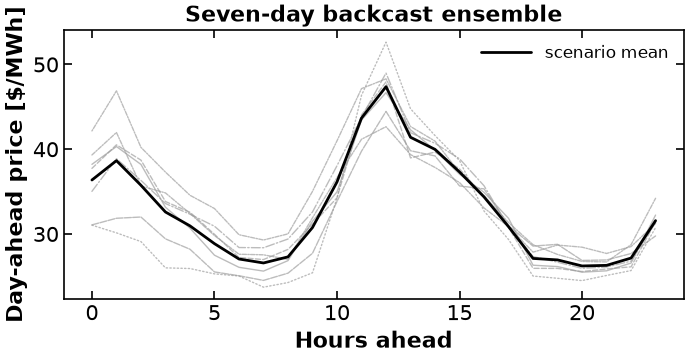

In [2]:
prices = pd.read_csv(
    Path("https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/data/Prices_DAM_ALTA2G_7_B1.csv"), names=["price"]
)["price"].to_numpy(float)

HORIZON = 24
N_SCENARIOS = 7
FIRST_BACKTEST_HOUR = 678
BACKTEST_HOURS = 48

assert FIRST_BACKTEST_HOUR >= N_SCENARIOS * 24
assert FIRST_BACKTEST_HOUR + BACKTEST_HOURS + HORIZON <= len(prices)


def backcast_scenarios(
    price_history, decision_hour, horizon=HORIZON, n_scenarios=N_SCENARIOS
):
    # Aligned historical price paths available by decision_hour.
    starts = [decision_hour - 24 * day for day in range(1, n_scenarios + 1)]
    scenarios = np.vstack(
        [price_history[start : start + horizon] for start in starts]
    )
    assert max(start + horizon for start in starts) <= decision_hour
    return scenarios


scenarios = backcast_scenarios(prices, FIRST_BACKTEST_HOUR)
fig, ax = plt.subplots(figsize=(8, 3.5))
for path in scenarios:
    ax.plot(path, color="0.60", alpha=0.65, linewidth=1)
ax.plot(scenarios.mean(axis=0), color="black", linewidth=2, label="scenario mean")
ax.set(
    xlabel="Hours ahead",
    ylabel="Day-ahead price [$/MWh]",
    title="Seven-day backcast ensemble",
)
ax.legend()
plt.show()

## Two-stage scenario-block model

Battery assumptions:

* 1-hour time steps;
* 1 MW charge and discharge limits;
* 4 MWh energy capacity;
* 92% one-way efficiency; and
* terminal energy equals initial energy over each planning horizon.

The root variables are the action implemented now. Every scenario block contains later recourse decisions and its own price path. Only the first action is nonanticipative, so this is a **two-stage approximation**: after hour 0, each scenario acts as though its entire path were revealed. A true multistage model would need a scenario tree and nonanticipativity at every shared history.

Binary operating modes prevent simultaneous charge and discharge. This matters when prices are negative: without the modes, artificial cycling losses can become profitable.

In [3]:
POWER_CAPACITY = 1.0  # MW
ENERGY_CAPACITY = 4.0  # MWh
EFFICIENCY = 0.92


def build_battery_model(
    price_scenarios,
    initial_energy,
    terminal_energy=None,
    risk_weight=0.0,
    cvar_confidence=0.90,
):
    # Two-stage battery-arbitrage model with one Block per scenario.
    price_scenarios = np.asarray(price_scenarios, dtype=float)
    n_scenarios, horizon = price_scenarios.shape
    terminal_energy = initial_energy if terminal_energy is None else terminal_energy

    m = pyo.ConcreteModel()
    m.S = pyo.RangeSet(0, n_scenarios - 1)
    m.T = pyo.RangeSet(0, horizon - 1)
    m.probability = pyo.Param(m.S, initialize=1 / n_scenarios)

    # Shared first-stage action.
    m.first_charge = pyo.Var(bounds=(0, POWER_CAPACITY))
    m.first_discharge = pyo.Var(bounds=(0, POWER_CAPACITY))
    m.first_mode = pyo.Var(domain=pyo.Binary)
    m.first_charge_limit = pyo.Constraint(
        expr=m.first_charge <= POWER_CAPACITY * m.first_mode
    )
    m.first_discharge_limit = pyo.Constraint(
        expr=m.first_discharge <= POWER_CAPACITY * (1 - m.first_mode)
    )

    def scenario_rule(block, scenario):
        block.price = pyo.Param(
            m.T, initialize=lambda block, hour: price_scenarios[scenario, hour]
        )
        block.charge = pyo.Var(m.T, domain=pyo.NonNegativeReals)
        block.discharge = pyo.Var(m.T, domain=pyo.NonNegativeReals)
        block.energy = pyo.Var(m.T, bounds=(0, ENERGY_CAPACITY))
        block.mode = pyo.Var(m.T, domain=pyo.Binary)

        block.charge_limit = pyo.Constraint(
            m.T,
            rule=lambda block, hour: block.charge[hour]
            <= POWER_CAPACITY * block.mode[hour],
        )
        block.discharge_limit = pyo.Constraint(
            m.T,
            rule=lambda block, hour: block.discharge[hour]
            <= POWER_CAPACITY * (1 - block.mode[hour]),
        )

        @block.Constraint(m.T)
        def energy_balance(block, hour):
            previous = initial_energy if hour == 0 else block.energy[hour - 1]
            return block.energy[hour] == (
                previous
                + EFFICIENCY * block.charge[hour]
                - block.discharge[hour] / EFFICIENCY
            )

        block.terminal = pyo.Constraint(
            expr=block.energy[horizon - 1] == terminal_energy
        )
        block.link_charge = pyo.Constraint(
            expr=block.charge[0] == m.first_charge
        )
        block.link_discharge = pyo.Constraint(
            expr=block.discharge[0] == m.first_discharge
        )
        block.link_mode = pyo.Constraint(expr=block.mode[0] == m.first_mode)
        block.profit = pyo.Expression(
            expr=sum(
                block.price[hour]
                * (block.discharge[hour] - block.charge[hour])
                for hour in m.T
            )
        )

    m.scenario = pyo.Block(m.S, rule=scenario_rule)
    m.expected_profit = pyo.Expression(
        expr=sum(
            m.probability[s] * m.scenario[s].profit for s in m.S
        )
    )

    if risk_weight > 0:
        m.profit_var = pyo.Var()
        for s in m.S:
            block = m.scenario[s]
            block.shortfall = pyo.Var(domain=pyo.NonNegativeReals)
            block.shortfall_constraint = pyo.Constraint(
                expr=block.shortfall >= m.profit_var - block.profit
            )
        m.lower_tail_cvar = pyo.Expression(
            expr=m.profit_var
            - sum(
                m.probability[s] * m.scenario[s].shortfall for s in m.S
            )
            / (1 - cvar_confidence)
        )
        m.objective = pyo.Objective(
            expr=(1 - risk_weight) * m.expected_profit
            + risk_weight * m.lower_tail_cvar,
            sense=pyo.maximize,
        )
    else:
        m.objective = pyo.Objective(expr=m.expected_profit, sense=pyo.maximize)
    return m


def solve(model):
    result = SOLVER.solve(model)
    assert pyo.check_optimal_termination(result), result.solver.termination_condition
    return model


def first_action(model):
    return (
        float(pyo.value(model.first_charge)),
        float(pyo.value(model.first_discharge)),
    )




## Value of information at one forecast origin

Using the profit convention:

* **RP** solves the two-stage recourse problem;
* **EEV** fixes the expected-value model's first action, then evaluates its recourse;
* **WS** averages independent perfect-information solutions;
* $\mathrm{VSS}=RP-EEV$; and
* $\mathrm{EVPI}=WS-RP$.

For a maximization problem, $WS\ge RP\ge EEV$ up to solver tolerance. Hour 678 is a fixed illustrative origin with nontrivial, but modest, value-of-information differences; it is not evidence that the same ranking holds throughout the data.

In [4]:
def information_metrics(price_scenarios, initial_energy=2.0):
    stochastic = solve(build_battery_model(price_scenarios, initial_energy))
    rp = float(pyo.value(stochastic.expected_profit))

    mean_path = np.asarray(price_scenarios).mean(axis=0, keepdims=True)
    expected_value_model = solve(build_battery_model(mean_path, initial_energy))
    expected_value_action = first_action(expected_value_model)

    eev_model = build_battery_model(price_scenarios, initial_energy)
    eev_model.first_charge.fix(expected_value_action[0])
    eev_model.first_discharge.fix(expected_value_action[1])
    eev = float(pyo.value(solve(eev_model).expected_profit))

    ws_values = []
    for s in range(np.asarray(price_scenarios).shape[0]):
        perfect_model = solve(
            build_battery_model(price_scenarios[s : s + 1], initial_energy)
        )
        ws_values.append(float(pyo.value(perfect_model.expected_profit)))
    ws = float(np.mean(ws_values))

    # HiGHS' MIP tolerance can leave sub-millidollar differences.
    tolerance = 1e-3
    assert ws + tolerance >= rp >= eev - tolerance
    return {
        "RP": rp,
        "EEV": eev,
        "WS": ws,
        "VSS": rp - eev,
        "EVPI": ws - rp,
    }


metrics = information_metrics(scenarios)
pd.Series(metrics, name="profit [$]").to_frame().round(2)

,profit [$]
RP,52.15
EEV,52.10
WS,52.59
VSS,0.05
EVPI,0.44


## Scenario-count and risk sensitivity

VSS and EVPI are properties of a model and scenario set, not universal constants. Recompute them as older backcast days are added.

For a risk-averse comparison, maximize a 50--50 blend of expected profit and the lower-tail 90% CVaR of profit. The lower-tail form rewards policies whose poor-scenario profit is less severe.

In [5]:
scenario_count_results = []
for count in [3, 5, 7]:
    count_metrics = information_metrics(scenarios[:count])
    scenario_count_results.append({"scenarios": count, **count_metrics})
pd.DataFrame(scenario_count_results).set_index("scenarios").round(2)

,RP,EEV,WS,VSS,EVPI
scenarios,,,,,
3,53.68,53.68,53.68,0.00,0.00
5,53.94,53.94,54.15,0.00,0.22
7,52.15,52.10,52.59,0.05,0.44


In [6]:
risk_neutral_model = solve(build_battery_model(scenarios, initial_energy=2.0))
risk_averse_model = solve(
    build_battery_model(
        scenarios,
        initial_energy=2.0,
        risk_weight=0.5,
        cvar_confidence=0.90,
    )
)

def scenario_profits(model):
    return np.array([pyo.value(model.scenario[s].profit) for s in model.S])

comparison = pd.DataFrame(
    {
        "risk neutral": [
            *first_action(risk_neutral_model),
            scenario_profits(risk_neutral_model).mean(),
            np.quantile(scenario_profits(risk_neutral_model), 0.10),
        ],
        "risk averse": [
            *first_action(risk_averse_model),
            scenario_profits(risk_averse_model).mean(),
            np.quantile(scenario_profits(risk_averse_model), 0.10),
        ],
    },
    index=["first charge [MW]", "first discharge [MW]", "mean profit [$]", "10th percentile profit [$]"],
)
comparison.round(2)

,risk neutral,risk averse
first charge [MW],0.00,0.00
first discharge [MW],0.55,0.80
mean profit [$],52.15,52.11
10th percentile profit [$],40.28,40.30


## Closed-loop backtest

At each hour, every implementable policy uses only the backcast ensemble available at that hour. It implements the shared first action, then updates energy and cash with the realized price.

The oracle instead uses the actual next 24 prices. It deliberately leaks future information and is included only as a perfect-forecast benchmark. Because rolling policies can finish with different energy, compare cash **plus terminal inventory value**, using the last observed price as a transparent salvage-price approximation.

In [7]:
def run_backtest(policy, price_history, first_hour, n_hours, initial_energy=2.0):
    energy = initial_energy
    cash = 0.0
    rows = []

    for hour in range(first_hour, first_hour + n_hours):
        backcasts = backcast_scenarios(price_history, hour)
        if policy == "stochastic":
            model = build_battery_model(backcasts, energy)
        elif policy == "expected value":
            model = build_battery_model(backcasts.mean(axis=0, keepdims=True), energy)
        elif policy == "risk averse":
            model = build_battery_model(
                backcasts, energy, risk_weight=0.5, cvar_confidence=0.90
            )
        elif policy == "perfect forecast":
            realized_path = price_history[hour : hour + HORIZON][None, :]
            model = build_battery_model(realized_path, energy)
        else:
            raise ValueError(policy)

        charge, discharge = first_action(solve(model))
        assert min(charge, discharge) <= 1e-7
        energy += EFFICIENCY * charge - discharge / EFFICIENCY
        assert -1e-7 <= energy <= ENERGY_CAPACITY + 1e-7
        cash += price_history[hour] * (discharge - charge)
        rows.append(
            {
                "hour": hour,
                "price": price_history[hour],
                "charge": charge,
                "discharge": discharge,
                "energy": energy,
                "cash": cash,
            }
        )
    return pd.DataFrame(rows)


policies = ["expected value", "stochastic", "risk averse", "perfect forecast"]
runs = {
    policy: run_backtest(
        policy, prices, FIRST_BACKTEST_HOUR, BACKTEST_HOURS
    )
    for policy in policies
}

terminal_price = prices[FIRST_BACKTEST_HOUR + BACKTEST_HOURS - 1]
summary = pd.DataFrame(
    {
        policy: [
            run.cash.iloc[-1],
            run.energy.iloc[-1],
            EFFICIENCY * terminal_price * run.energy.iloc[-1],
            run.cash.iloc[-1] + EFFICIENCY * terminal_price * run.energy.iloc[-1],
        ]
        for policy, run in runs.items()
    },
    index=[
        "realized cash [$]",
        "final energy [MWh]",
        "terminal inventory value [$]",
        "cash + terminal inventory value [$]",
    ],
)
summary.round(2)

,expected value,stochastic,risk averse,perfect forecast
realized cash [$],24.88,27.49,37.54,138.04
final energy [MWh],4.00,4.00,3.58,0.32
terminal inventory value [$],104.95,104.95,93.95,8.40
cash + terminal inventory value [$],129.82,132.43,131.49,146.44


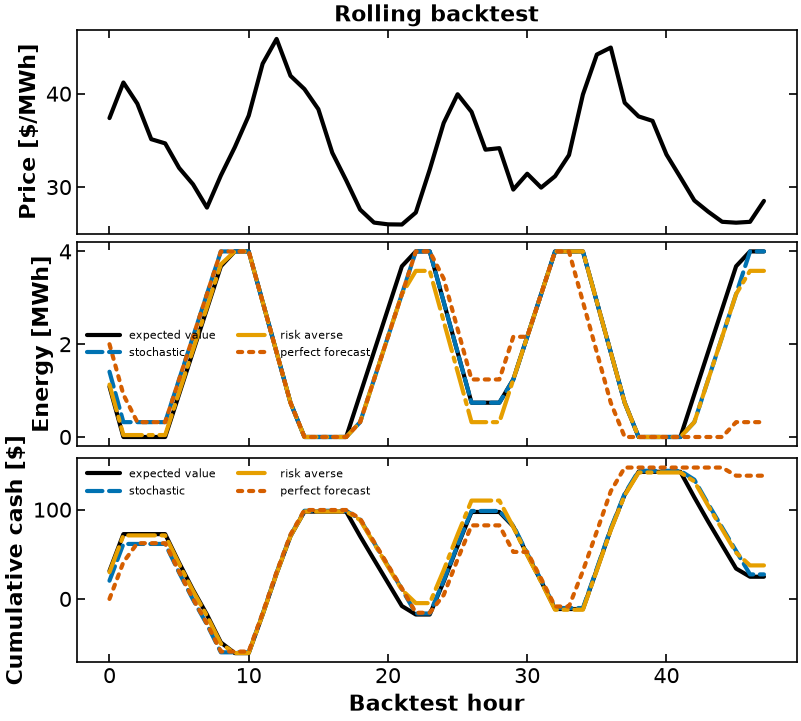

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(8, 7.2), sharex=True, layout="constrained")
hours = np.arange(BACKTEST_HOURS)
styles = {
    "expected value": ("black", "-"),
    "stochastic": ("#0072B2", "--"),
    "risk averse": ("#E69F00", "-."),
    "perfect forecast": ("#D55E00", ":"),
}

axes[0].plot(hours, runs["stochastic"].price, color="black")
axes[0].set(ylabel="Price [$/MWh]", title="Rolling backtest")

for policy in policies:
    color, linestyle = styles[policy]
    axes[1].plot(hours, runs[policy].energy, color=color, linestyle=linestyle, label=policy)
    axes[2].plot(hours, runs[policy].cash, color=color, linestyle=linestyle, label=policy)

axes[1].set_ylabel("Energy [MWh]")
axes[2].set(xlabel="Backtest hour", ylabel="Cumulative cash [$]")
axes[1].legend(ncol=2, fontsize=8)
axes[2].legend(ncol=2, fontsize=8)
plt.show()

## Interpret

1. Why can EVPI be positive when VSS is small?
2. How does scenario count change the metrics? Is the change monotone?
3. Does the risk-averse first action improve the lower tail, and what happens to mean profit?
4. Why is cash alone an unfair comparison when policies finish with different stored energy?
5. How much inventory-adjusted value separates the implementable policies from the oracle in this 48-hour sample?
6. Which assumption would you improve first: scenario construction, terminal valuation, battery degradation, market timing, or the two-stage information pattern?

One short backtest is evidence, not proof. A serious forecast comparison needs repeated out-of-sample windows and must charge every policy the same battery and market costs.